# Cuaderno 08 · Métodos de estimación por dentro: PSM, IPW, IV y diferencias en diferencias

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 8 de 10

> Cuaderno reproducible asociado al artículo divulgativo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

El cuaderno 07 usó DoWhy como caja de herramientas y dejó una promesa: con un **diseño cuidadoso**, los métodos observacionales se acercan al efecto experimental. Este capítulo abre los estimadores **por dentro**, implementándolos a mano para entender sus supuestos. Cuatro familias: **emparejamiento por propensión (PSM)** e **inverse probability weighting (IPW)** —que asumen *selección sobre observables*—; y **variables instrumentales (IV)** y **diferencias en diferencias (DiD)** —que identifican efectos aun con **confusión no observada**, a cambio de otros supuestos—. El experimento NSW sigue siendo el patrón de oro para juzgarlos.

## Contenido y objetivos

1. **Emparejamiento por propensión (PSM)** — el puntaje de propensión, el teorema de balanceo y el soporte común.
2. **Ponderación inversa (IPW)** — pseudo-población balanceada y el estimador de Horvitz–Thompson.
3. **Variables instrumentales (IV)** — identificación con confusor no observado vía 2SLS.
4. **Diferencias en diferencias (DiD)** — explotar dos periodos y el supuesto de tendencias paralelas.

**Objetivos.** Definir, **implementar a mano** y demostrar numéricamente cada estimador; entender el supuesto que lo identifica; y medir cuánto recupera del efecto experimental del NSW.

*(Construido por pasos: esta versión incluye la Sección 1; las Secciones 2–4 se añaden a continuación.)*

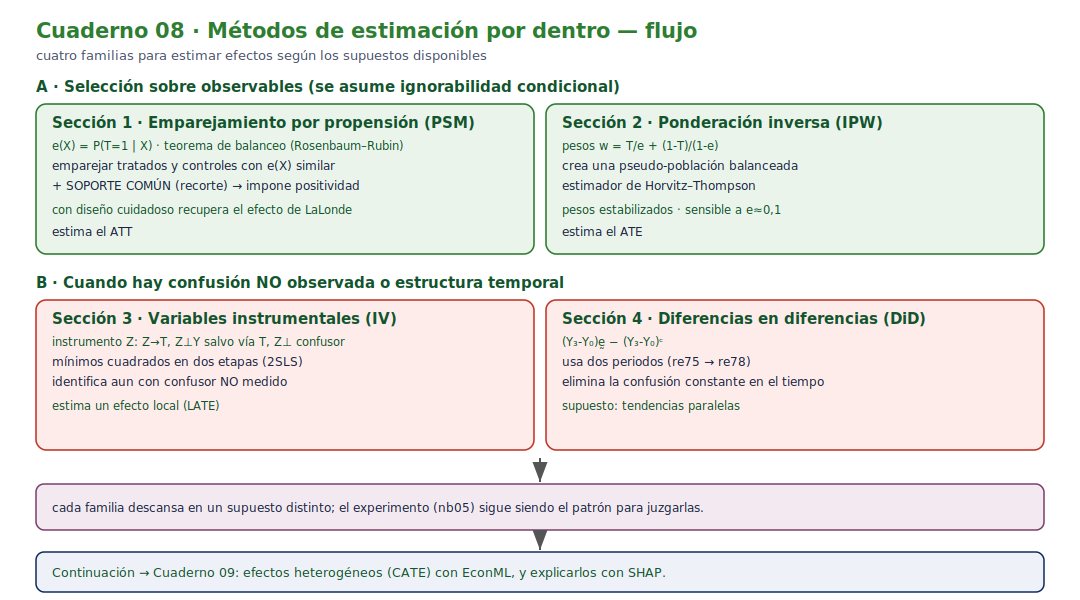

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/08_flujo.svg')
if not _svg.exists():
    _svg = Path('img/08_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Configuración y datos
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_nsw, load_lalonde_obs

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE); np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})

covs = ["edad", "educacion", "afroamericano", "hispano", "casado", "sin_grado", "re75"]
exp = load_nsw()
cps = load_lalonde_obs("cps")
gold = exp.loc[exp.tratamiento == 1, "re78"].mean() - exp.loc[exp.tratamiento == 0, "re78"].mean()
naive_cps = cps.loc[cps.tratamiento == 1, "re78"].mean() - cps.loc[cps.tratamiento == 0, "re78"].mean()
print(f"patrón de oro (experimental) = {gold:.0f} USD")
print(f"diferencia ingenua (CPS)     = {naive_cps:.0f} USD")

patrón de oro (experimental) = 886 USD
diferencia ingenua (CPS)     = -8870 USD


## Sección 1 · Emparejamiento por propensión (PSM)

Para estimar el efecto sin experimento se busca, para cada tratado, controles **comparables** en las covariables $X$. Con muchas covariables el emparejamiento directo es inviable (maldición de la dimensionalidad). La solución es reducir $X$ a un **escalar**.

> **Definición 1.1 (puntaje de propensión).** El *puntaje de propensión* es la probabilidad de recibir el tratamiento dado $X$:
> $$ e(x)=P(T{=}1\mid X{=}x). $$

> **Teorema 1.1 (balanceo; Rosenbaum & Rubin, 1983).** El puntaje de propensión es un *balancing score*:
> $$ \text{(a)}\quad X\perp T\mid e(X); \qquad \text{(b) si } \{Y(0),Y(1)\}\perp T\mid X \text{ (ignorabilidad), entonces } \{Y(0),Y(1)\}\perp T\mid e(X). $$
> Es decir: **basta condicionar en el escalar $e(X)$** —no en todo $X$— para eliminar la confusión.
>
> **Demostración de (a).** Basta ver que $P(T{=}1\mid X, e(X))$ depende de $X$ solo a través de $e(X)$. En efecto, como $e(X)$ es función de $X$, $P(T{=}1\mid X, e(X))=P(T{=}1\mid X)=e(X)$, que es constante dentro de cada nivel de $e(X)$. Por tanto $T$ es independiente de $X$ condicionado a $e(X)$. La parte (b) se sigue combinando (a) con la ignorabilidad. $\blacksquare$

> **Definición 1.2 (emparejamiento, ATT).** Se estima cada $\hat e(X)$ con un modelo (aquí, regresión logística), se **empareja** cada tratado con el control (o $k$ controles) de propensión más cercana, y se estima el efecto sobre los tratados como el promedio de las diferencias emparejadas:
> $$ \widehat{\mathrm{ATT}}=\frac1{n_1}\sum_{i:T_i=1}\Big(Y_i-\tfrac1k\textstyle\sum_{j\in\mathcal M(i)}Y_j\Big). $$

> **Definición 1.3 (soporte común).** Restringir el análisis a la región donde **coexisten** propensiones de ambos grupos, $e(X)\in[\,\max(\min_T,\min_C),\ \min(\max_T,\max_C)\,]$. Es la versión operativa de la **positividad** (cuaderno 05): sin solape no hay con quién emparejar.

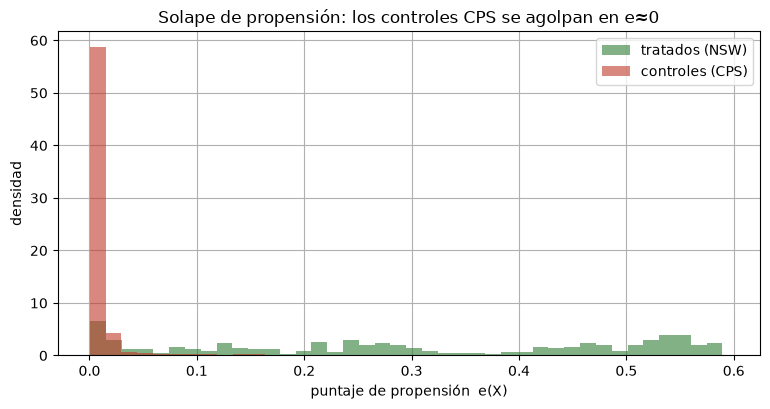

In [3]:
# Puntaje de propensión y solape en la muestra CPS
def propension(df, covs=covs):
    m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
    m.fit(df[covs], df["tratamiento"])
    return m.predict_proba(df[covs])[:, 1]

e_cps = propension(cps)
plt.figure(figsize=(7.8, 4.2))
plt.hist(e_cps[cps.tratamiento.values == 1], bins=40, density=True, alpha=.6,
         color="#2e7d32", label="tratados (NSW)")
plt.hist(e_cps[cps.tratamiento.values == 0], bins=40, density=True, alpha=.6,
         color="#c0392b", label="controles (CPS)")
plt.xlabel("puntaje de propensión  e(X)"); plt.ylabel("densidad")
plt.title("Solape de propensión: los controles CPS se agolpan en e≈0")
plt.legend(); plt.tight_layout(); plt.show()

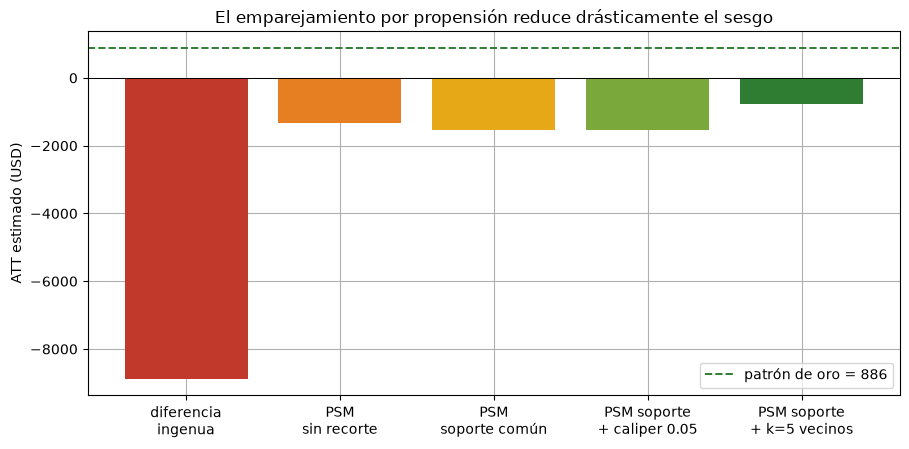

  diferencia ingenua         =    -8870 USD
  PSM sin recorte            =    -1339 USD
  PSM soporte común          =    -1549 USD
  PSM soporte + caliper 0.05 =    -1549 USD
  PSM soporte + k=5 vecinos  =     -772 USD


In [4]:
# Emparejamiento por propensión (implementación a mano), con variantes
def psm_att(df, caliper=None, soporte_comun=True, k=1):
    d = df.copy(); d["e"] = propension(d)
    t = d[d.tratamiento == 1].copy(); c = d[d.tratamiento == 0].copy()
    if soporte_comun:
        lo = max(t["e"].min(), c["e"].min()); hi = min(t["e"].max(), c["e"].max())
        t = t[(t["e"] >= lo) & (t["e"] <= hi)]; c = c[(c["e"] >= lo) & (c["e"] <= hi)]
    nn = NearestNeighbors(n_neighbors=k).fit(c[["e"]].values)
    dist, idx = nn.kneighbors(t[["e"]].values)
    keep = np.ones(len(t), bool) if caliper is None else dist[:, 0] <= caliper
    att = (t["re78"].values[keep] - c["re78"].values[idx[keep]].mean(axis=1)).mean()
    return att, int(keep.sum()), len(t)

variantes = {
    "diferencia\ningenua":        (naive_cps, None),
    "PSM\nsin recorte":           psm_att(cps, None, False)[0],
    "PSM\nsoporte común":         psm_att(cps, None, True)[0],
    "PSM soporte\n+ caliper 0.05": psm_att(cps, 0.05, True)[0],
    "PSM soporte\n+ k=5 vecinos":  psm_att(cps, 0.05, True, 5)[0],
}
vals = [v if np.isscalar(v) else v[0] for v in variantes.values()]
plt.figure(figsize=(9.2, 4.6))
plt.bar(range(len(vals)), vals, color=["#c0392b", "#e67e22", "#e6a817", "#7aa83a", "#2e7d32"])
plt.axhline(gold, color="#2e7d32", ls="--", lw=1.4, label=f"patrón de oro = {gold:.0f}")
plt.axhline(0, color="k", lw=.7)
plt.xticks(range(len(vals)), list(variantes)); plt.ylabel("ATT estimado (USD)")
plt.title("El emparejamiento por propensión reduce drásticamente el sesgo")
plt.legend(); plt.tight_layout(); plt.show()
for nombre, v in zip(variantes, vals):
    print(f"  {nombre.replace(chr(10),' '):26s} = {v:8.0f} USD")

> **Observación 1.1.** En el experimento, PSM sería innecesario (los grupos ya están balanceados). En **CPS** el emparejamiento **reduce el sesgo en torno a un 85–90 %**: de la diferencia ingenua $-\$8.870$ a unos $-\$800$ a $-\$1.500$. Pero el signo **sigue siendo negativo**: PSM no recupera del todo el $+\$886$. La razón es un **confusor faltante** —no se midió el ingreso de 1974 ($re_{74}$)—; Dehejia & Wahba (1999) mostraron que, incluyéndolo (dos periodos de ingreso previo), el emparejamiento alcanza valores positivos cercanos al experimental. Aquí el **soporte común no recorta** porque la enorme muestra CPS cubre todo el rango de propensión; su papel es de **salvaguarda** cuando el solape es parcial. La moraleja: el emparejamiento ayuda enormemente, pero **no inventa** la información de un confusor que no se midió.

## Sección 2 · Ponderación por la inversa de la propensión (IPW)

En vez de emparejar, IPW **repondera** a cada individuo por la inversa de su probabilidad de haber recibido el tratamiento que recibió, creando una *pseudo-población* en la que tratamiento y covariables son independientes.

> **Definición 2.1 (estimador IPW / Horvitz–Thompson).** Con peso $w_i=\dfrac{T_i}{e(X_i)}+\dfrac{1-T_i}{1-e(X_i)}$, el estimador del ATE es
> $$ \widehat{\mathrm{ATE}}_{\mathrm{IPW}}=\frac1n\sum_{i=1}^n\left[\frac{T_i\,Y_i}{e(X_i)}-\frac{(1-T_i)\,Y_i}{1-e(X_i)}\right]. $$

> **Proposición 2.1 (insesgadez del IPW).** Bajo ignorabilidad $\{Y(0),Y(1)\}\perp T\mid X$ y positividad $0<e(X)<1$,
> $$ \mathbb E\!\left[\frac{T\,Y}{e(X)}\right]=\mathbb E[Y(1)],\qquad \mathbb E\!\left[\frac{(1-T)\,Y}{1-e(X)}\right]=\mathbb E[Y(0)]. $$
>
> **Demostración.** Por consistencia $T\,Y=T\,Y(1)$. Condicionando en $X$ y usando $T\perp Y(1)\mid X$ (ignorabilidad):
> $$ \mathbb E\!\left[\frac{T\,Y(1)}{e(X)}\,\Big|\,X\right]=\frac{\mathbb E[T\mid X]\,\mathbb E[Y(1)\mid X]}{e(X)}=\frac{e(X)\,\mathbb E[Y(1)\mid X]}{e(X)}=\mathbb E[Y(1)\mid X]. $$
> Por la ley de esperanzas iteradas, $\mathbb E[\,T Y/e(X)\,]=\mathbb E[\mathbb E[Y(1)\mid X]]=\mathbb E[Y(1)]$. El control es simétrico; la positividad asegura que los denominadores no se anulan. $\blacksquare$

> **Definición 2.2 (pesos estabilizados).** Para reducir la varianza cuando $e(X)$ es extrema, se usan $sw_i=\dfrac{T_i\,P(T{=}1)}{e(X_i)}+\dfrac{(1-T_i)\,P(T{=}0)}{1-e(X_i)}$ y el estimador de razón $\sum sw_iY_i/\sum sw_i$ por grupo.

> **Observación 2.1.** La insesgadez vale en la **población** (esperanzas), pero en muestras finitas el IPW es **muy sensible** a propensiones cercanas a 0 o 1: un solo individuo con $e\approx 0$ recibe un peso gigantesco. La positividad deja de ser un tecnicismo y se vuelve el talón de Aquiles del método.

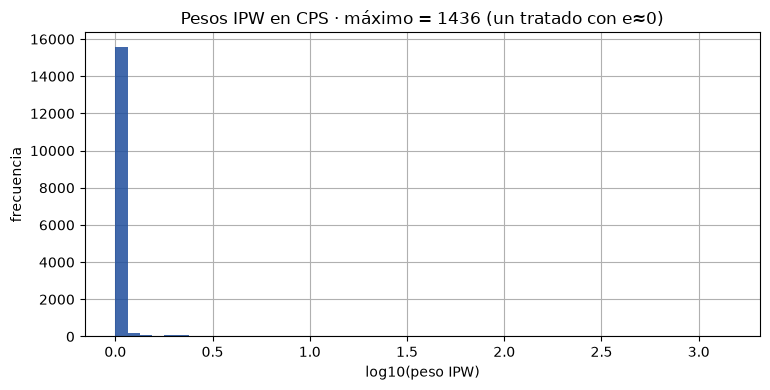

peso máximo = 1436  ·  pesos > 100: 20 individuos


In [5]:
# Distribución de los pesos IPW en CPS: unos pocos pesos enormes
e_c = np.clip(propension(cps), 1e-6, 1 - 1e-6)
T_c = cps["tratamiento"].values
w = np.where(T_c == 1, 1 / e_c, 1 / (1 - e_c))
plt.figure(figsize=(7.8, 4))
plt.hist(np.log10(w), bins=50, color="#1f4e9c", alpha=.85)
plt.xlabel("log10(peso IPW)"); plt.ylabel("frecuencia")
plt.title(f"Pesos IPW en CPS · máximo = {w.max():.0f} (un tratado con e≈0)")
plt.tight_layout(); plt.show()
print(f"peso máximo = {w.max():.0f}  ·  pesos > 100: {(w > 100).sum()} individuos")

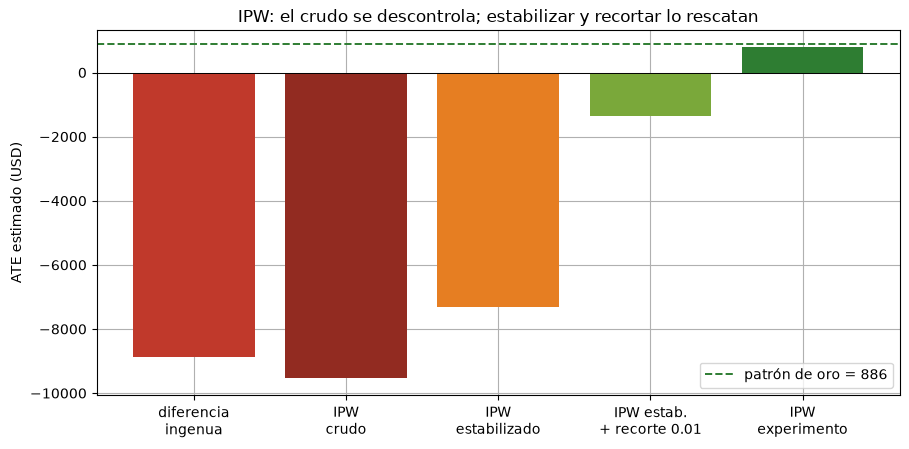

  diferencia ingenua         =    -8870 USD
  IPW crudo                  =    -9542 USD
  IPW estabilizado           =    -7301 USD
  IPW estab. + recorte 0.01  =    -1343 USD
  IPW experimento            =      798 USD


In [6]:
# Estimaciones IPW: crudo, estabilizado, con recorte, y en el experimento
def ipw_ate(df, estabilizado=True, recorte=None):
    e = np.clip(propension(df), 1e-6, 1 - 1e-6)
    T = df["tratamiento"].values; Y = df["re78"].values
    if recorte is not None:
        m = (e > recorte) & (e < 1 - recorte); e, T, Y = e[m], T[m], Y[m]
    if estabilizado:
        p1 = T.mean()
        w1 = p1 * T / e; w0 = (1 - p1) * (1 - T) / (1 - e)
        return np.sum(w1 * Y) / np.sum(w1) - np.sum(w0 * Y) / np.sum(w0)
    return np.mean(T * Y / e) - np.mean((1 - T) * Y / (1 - e))

estim_ipw = {
    "diferencia\ningenua":          naive_cps,
    "IPW\ncrudo":                   ipw_ate(cps, estabilizado=False),
    "IPW\nestabilizado":            ipw_ate(cps, estabilizado=True),
    "IPW estab.\n+ recorte 0.01":   ipw_ate(cps, estabilizado=True, recorte=0.01),
    "IPW\nexperimento":             ipw_ate(exp, estabilizado=True),
}
vals = list(estim_ipw.values())
plt.figure(figsize=(9.2, 4.6))
plt.bar(range(len(vals)), vals, color=["#c0392b", "#922b21", "#e67e22", "#7aa83a", "#2e7d32"])
plt.axhline(gold, color="#2e7d32", ls="--", lw=1.4, label=f"patrón de oro = {gold:.0f}")
plt.axhline(0, color="k", lw=.7)
plt.xticks(range(len(vals)), list(estim_ipw)); plt.ylabel("ATE estimado (USD)")
plt.title("IPW: el crudo se descontrola; estabilizar y recortar lo rescatan")
plt.legend(); plt.tight_layout(); plt.show()
for k, v in estim_ipw.items():
    print(f"  {k.replace(chr(10),' '):26s} = {v:8.0f} USD")

> **Observación 2.2.** En el **experimento**, el IPW estabilizado recupera el efecto ($\approx 798$). En **CPS**, el IPW **crudo es catastrófico** ($\approx -9.500$, peor que no ajustar) por los pesos extremos; **estabilizarlo** ayuda y **recortar** las propensiones cercanas a 0/1 lo lleva a $\approx -\$1.300$, a la par del emparejamiento. Pero, igual que el PSM, **no cruza a positivo**: persiste el sesgo del confusor no medido. Dos métodos distintos (emparejar vs. reponderar) convergen al mismo techo, fijado por los **supuestos**, no por el algoritmo.

## Sección 3 · Variables instrumentales (IV)

PSM e IPW asumen *selección sobre observables*: que **todos** los confusores se midieron (ignorabilidad). Cuando hay un confusor **no observado** $U$, el ajuste por puerta trasera es imposible —ninguna covariable lo cierra—. Las **variables instrumentales** ofrecen otra vía de identificación, a cambio de un supuesto distinto: la existencia de un *instrumento*.

> **Definición 3.1 (instrumento válido).** Una variable $Z$ es un *instrumento* para el efecto de $T$ sobre $Y$ si cumple:
> 1. **Relevancia:** $Z$ afecta a $T$ — $\mathrm{Cov}(Z,T)\neq 0$.
> 2. **Exclusión:** $Z$ afecta a $Y$ **solo a través de** $T$ (no hay flecha directa $Z\to Y$).
> 3. **Exogeneidad:** $Z$ es independiente del confusor — $Z\perp U$ (no hay puerta trasera de $Z$ a $Y$).

> **Proposición 3.1 (estimador de Wald).** En el modelo lineal $T=\alpha Z+\delta U+\nu$, $Y=\beta T+\gamma U+\varepsilon$, con $Z$ válido ($Z\perp U,\varepsilon,\nu$ y $\alpha\neq 0$), el efecto causal es
> $$ \beta=\frac{\mathrm{Cov}(Z,Y)}{\mathrm{Cov}(Z,T)}. $$
>
> **Demostración.** Por bilinealidad y usando la exclusión/exogeneidad ($\mathrm{Cov}(Z,U)=\mathrm{Cov}(Z,\varepsilon)=0$):
> $$ \mathrm{Cov}(Z,Y)=\mathrm{Cov}(Z,\beta T+\gamma U+\varepsilon)=\beta\,\mathrm{Cov}(Z,T)+\gamma\underbrace{\mathrm{Cov}(Z,U)}_{0}+\underbrace{\mathrm{Cov}(Z,\varepsilon)}_{0}=\beta\,\mathrm{Cov}(Z,T). $$
> Dividiendo por $\mathrm{Cov}(Z,T)\neq 0$ (relevancia) se obtiene $\beta$. Nótese que **no aparece $U$**: el instrumento identifica el efecto pese al confusor no observado. $\blacksquare$

> **Definición 3.2 (mínimos cuadrados en dos etapas, 2SLS).** (1) Regresar $T$ sobre $Z$ y obtener la predicción $\hat T$ —la parte de $T$ *movida por el instrumento*, libre de $U$—; (2) regresar $Y$ sobre $\hat T$. El coeficiente es el efecto. Generaliza el estimador de Wald e incorpora covariables.

> **Observación 3.1 (LATE).** Con efectos **heterogéneos** y un instrumento binario, el 2SLS no estima el ATE sino el **LATE** (*Local Average Treatment Effect*): el efecto promedio sobre los *compliers*, quienes cambian su tratamiento en respuesta al instrumento (Imbens & Angrist, 1994).

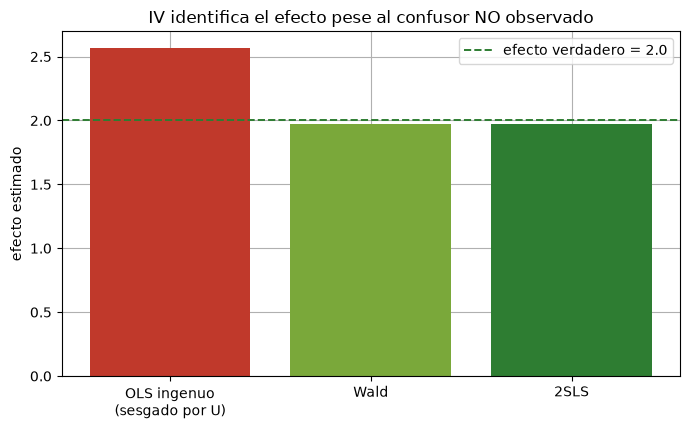

  OLS ingenuo (sesgado por U) = 2.569   (verdadero 2.0)
  Wald                     = 1.974   (verdadero 2.0)
  2SLS                     = 1.974   (verdadero 2.0)


In [7]:
# SCM con confusor NO observado U e instrumento Z (efecto verdadero = 2.0)
def simular_iv(n=8000, fuerza=0.8, seed=0):
    r = np.random.default_rng(seed)
    U = r.normal(0, 1, n)                       # confusor NO observado
    Z = r.normal(0, 1, n)                       # instrumento
    T = fuerza * Z + 1.0 * U + r.normal(0, 1, n)
    Y = 2.0 * T + 1.5 * U + r.normal(0, 1, n)   # beta verdadero = 2.0
    return pd.DataFrame({"Z": Z, "T": T, "Y": Y})

def ols_ingenuo(df):
    return LinearRegression().fit(df[["T"]], df["Y"]).coef_[0]
def wald(df):
    return np.cov(df["Z"].values, df["Y"].values)[0, 1] / np.cov(df["Z"].values, df["T"].values)[0, 1]
def dos_etapas(df):
    T_hat = LinearRegression().fit(df[["Z"]], df["T"]).predict(df[["Z"]])
    return LinearRegression().fit(T_hat.reshape(-1, 1), df["Y"]).coef_[0]

div = simular_iv()
estim_iv = {"OLS ingenuo\n(sesgado por U)": ols_ingenuo(div),
            "Wald": wald(div), "2SLS": dos_etapas(div)}
plt.figure(figsize=(7, 4.4))
plt.bar(range(3), list(estim_iv.values()), color=["#c0392b", "#7aa83a", "#2e7d32"])
plt.axhline(2.0, color="#2e7d32", ls="--", lw=1.4, label="efecto verdadero = 2.0")
plt.xticks(range(3), list(estim_iv)); plt.ylabel("efecto estimado")
plt.title("IV identifica el efecto pese al confusor NO observado")
plt.legend(); plt.tight_layout(); plt.show()
for k, v in estim_iv.items():
    print(f"  {k.replace(chr(10),' '):24s} = {v:.3f}   (verdadero 2.0)")

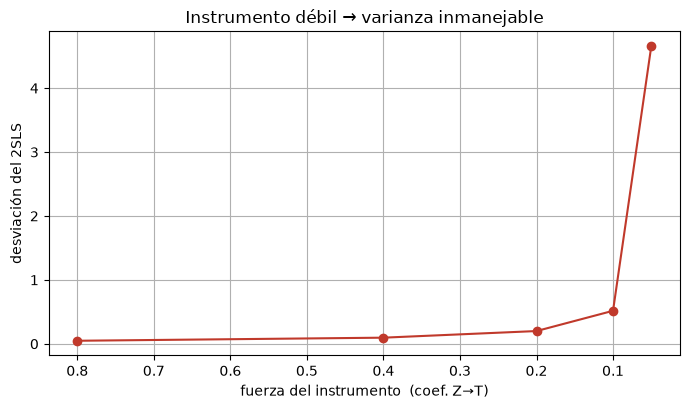

desviación del 2SLS por fuerza: {0.8: np.float64(0.05), 0.4: np.float64(0.1), 0.2: np.float64(0.2), 0.1: np.float64(0.52), 0.05: np.float64(4.66)}


In [8]:
# El problema del instrumento DÉBIL: la varianza del 2SLS explota
fuerzas = [0.8, 0.4, 0.2, 0.1, 0.05]
desv = [np.std([dos_etapas(simular_iv(2000, g, s)) for s in range(150)]) for g in fuerzas]
plt.figure(figsize=(7, 4.2))
plt.plot(fuerzas, desv, "-o", color="#c0392b")
plt.xlabel("fuerza del instrumento  (coef. Z→T)"); plt.ylabel("desviación del 2SLS")
plt.title("Instrumento débil → varianza inmanejable")
plt.gca().invert_xaxis(); plt.tight_layout(); plt.show()
print("desviación del 2SLS por fuerza:", {g: round(d, 2) for g, d in zip(fuerzas, desv)})

> **Observación 3.2 (instrumento débil).** El OLS ingenuo da $\approx 2.57$ (sesgado al alza por $U$); el estimador de Wald y el 2SLS recuperan $\approx 1.97\approx 2.0$, **sin medir $U$**. Pero la identificación se apoya en la **relevancia**: si el instrumento es **débil** ($\mathrm{Cov}(Z,T)\approx 0$), el denominador se acerca a cero y la varianza del 2SLS **explota** (la desviación pasa de $0.05$ a más de $4$ cuando la fuerza baja de $0.8$ a $0.05$). Un instrumento débil puede ser peor que no usar ninguno. Además, los supuestos de **exclusión** y **exogeneidad** no son verificables con los datos: como siempre, la identificación es una **apuesta sustantiva**.

## Sección 4 · Diferencias en diferencias (DiD)

Cuando hay **dos periodos** (antes/después) y un grupo tratado y otro de control, se puede eliminar la confusión que es **constante en el tiempo** —aunque sea **no observada**— comparando *cambios* en lugar de *niveles*. El NSW lo permite: el ingreso de 1975 (`re75`, pre) y el de 1978 (`re78`, post).

> **Definición 4.1 (estimador de diferencias en diferencias).**
> $$ \widehat{\mathrm{DiD}}=\big(\bar Y^{\text{post}}_{T=1}-\bar Y^{\text{pre}}_{T=1}\big)-\big(\bar Y^{\text{post}}_{T=0}-\bar Y^{\text{pre}}_{T=0}\big). $$
> Primera diferencia: el cambio temporal dentro de cada grupo (elimina lo que es fijo en cada individuo). Segunda diferencia: resta el cambio del control (elimina las tendencias comunes).

> **Definición 4.2 (tendencias paralelas).** En ausencia de tratamiento, el resultado de tratados y controles habría evolucionado **en paralelo**:
> $$ \mathbb E\big[Y^{\text{post}}(0)-Y^{\text{pre}}(0)\mid T{=}1\big]=\mathbb E\big[Y^{\text{post}}(0)-Y^{\text{pre}}(0)\mid T{=}0\big]. $$

> **Proposición 4.1 (identificación por DiD).** Bajo tendencias paralelas (y consistencia), $\widehat{\mathrm{DiD}}$ estima el **ATT**.
>
> **Demostración.** Por consistencia, en el grupo tratado se observa $Y^{\text{post}}(1)$ y en el control $Y^{\text{post}}(0)$. Escribamos el cambio observado de los tratados como
> $$ \mathbb E[Y^{\text{post}}\!-Y^{\text{pre}}\mid T{=}1]=\underbrace{\mathbb E[Y^{\text{post}}(1)-Y^{\text{post}}(0)\mid T{=}1]}_{\mathrm{ATT}}+\mathbb E[Y^{\text{post}}(0)-Y^{\text{pre}}(0)\mid T{=}1]. $$
> Por tendencias paralelas, el segundo término iguala al cambio del control $\mathbb E[Y^{\text{post}}-Y^{\text{pre}}\mid T{=}0]$. Restándolo se cancela y queda el ATT. $\blacksquare$

> **Observación 4.1.** La fuerza del DiD es que la confusión **constante en el tiempo** —incluida la **no observada**, como el nivel socioeconómico de base que tanto sesgó las estimaciones transversales— se **cancela** en la primera diferencia. Su talón de Aquiles es el supuesto de **tendencias paralelas**, no verificable sin más periodos.

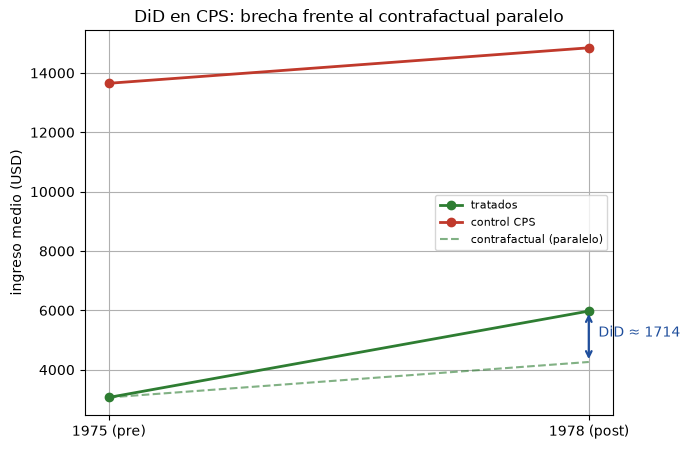

In [9]:
# DiD sobre NSW: el cambio re75 -> re78, tratados menos control
def did(df):
    t = df[df.tratamiento == 1]; c = df[df.tratamiento == 0]
    return (t["re78"].mean() - t["re75"].mean()) - (c["re78"].mean() - c["re75"].mean())

psid = load_lalonde_obs("psid")
# Figura · el diagrama 2x2 del DiD en CPS
t = cps[cps.tratamiento == 1]; c = cps[cps.tratamiento == 0]
cf = t["re75"].mean() + (c["re78"].mean() - c["re75"].mean())   # contrafactual paralelo
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot([0, 1], [t["re75"].mean(), t["re78"].mean()], "-o", color="#2e7d32", lw=2, label="tratados")
ax.plot([0, 1], [c["re75"].mean(), c["re78"].mean()], "-o", color="#c0392b", lw=2, label="control CPS")
ax.plot([0, 1], [t["re75"].mean(), cf], "--", color="#2e7d32", alpha=.6, label="contrafactual (paralelo)")
ax.annotate("", xy=(1, t["re78"].mean()), xytext=(1, cf),
            arrowprops=dict(arrowstyle="<->", color="#1f4e9c", lw=1.6))
ax.text(1.02, (t["re78"].mean() + cf) / 2, f"DiD ≈ {did(cps):.0f}", color="#1f4e9c", fontsize=10)
ax.set_xticks([0, 1]); ax.set_xticklabels(["1975 (pre)", "1978 (post)"])
ax.set_ylabel("ingreso medio (USD)"); ax.set_title("DiD en CPS: brecha frente al contrafactual paralelo")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

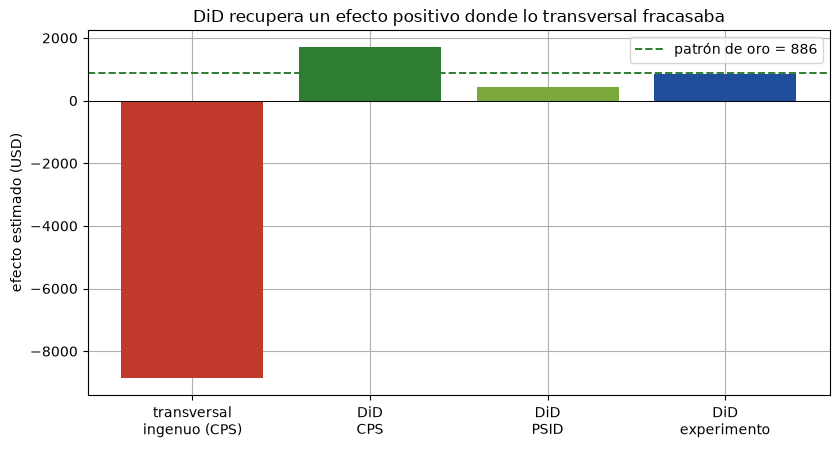

  transversal ingenuo (CPS)  =    -8870 USD
  DiD CPS                    =     1714 USD
  DiD PSID                   =      420 USD
  DiD experimento            =      847 USD


In [10]:
# DiD frente a los métodos transversales (que fracasaban en CPS)
estim_did = {
    "transversal\ningenuo (CPS)": naive_cps,
    "DiD\nCPS":                    did(cps),
    "DiD\nPSID":                   did(psid),
    "DiD\nexperimento":            did(exp),
}
vals = list(estim_did.values())
plt.figure(figsize=(8.5, 4.6))
plt.bar(range(len(vals)), vals, color=["#c0392b", "#2e7d32", "#7aa83a", "#1f4e9c"])
plt.axhline(gold, color="#2e7d32", ls="--", lw=1.4, label=f"patrón de oro = {gold:.0f}")
plt.axhline(0, color="k", lw=.7)
plt.xticks(range(len(vals)), list(estim_did)); plt.ylabel("efecto estimado (USD)")
plt.title("DiD recupera un efecto positivo donde lo transversal fracasaba")
plt.legend(); plt.tight_layout(); plt.show()
for k, v in estim_did.items():
    print(f"  {k.replace(chr(10),' '):26s} = {v:8.0f} USD")

> **Observación 4.2.** El DiD **sí** recupera un efecto **positivo** en datos observacionales: $+\$1.714$ con CPS y $+\$420$ con PSID, frente al $-\$8.870$ transversal y a los $\approx-\$1.300$ de PSM/IPW. La razón es estructural: gran parte de la confusión que arruinaba las estimaciones era el **nivel de ingreso de base** (constante en el tiempo), que la primera diferencia **elimina**. El DiD experimental ($+\$847$) coincide con el patrón de oro, lo que respalda la plausibilidad de las tendencias paralelas aquí. **El método correcto depende de la estructura de la confusión**, no de su sofisticación.

## Síntesis

Cuatro familias, cuatro supuestos de identificación distintos:

| Método | Supuesto clave | Identifica | En CPS recupera |
|---|---|---|---|
| **PSM** | ignorabilidad + solape (selección sobre observables) | ATT | $\approx-\$1.300$ (queda negativo) |
| **IPW** | ídem (sensible a positividad) | ATE | $\approx-\$1.300$ (con recorte) |
| **IV** | instrumento válido (relevancia, exclusión, exogeneidad) | LATE | recupera el efecto pese a confusor **no observado** (demostrado en simulación) |
| **DiD** | tendencias paralelas (dos periodos) | ATT | $\approx+\$1.714$ (recupera el signo) |

- PSM e IPW **reducen** el sesgo pero no lo eliminan: su supuesto (medir todos los confusores) **falla** aquí (falta el ingreso de 1974).
- IV y DiD identifican aun con confusión **no observada**, a cambio de otros supuestos —un instrumento, o tendencias paralelas—.
- Ninguno es universal: la elección es **sustantiva**, dictada por la estructura causal del problema (cuaderno 06), no por el algoritmo.
- El cuaderno 09 vuelve a la IA explicativa, ahora del lado causal: estima efectos **heterogéneos** (CATE) con EconML y los explica con SHAP.

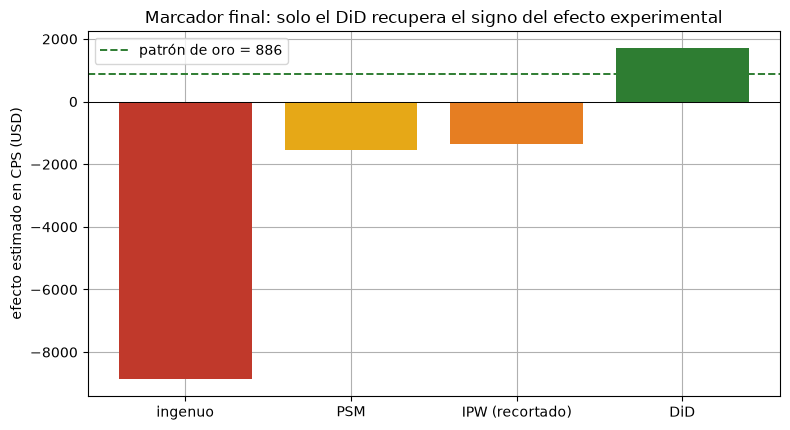

  ingenuo            =    -8870 USD   (patrón 886)
  PSM                =    -1549 USD   (patrón 886)
  IPW (recortado)    =    -1343 USD   (patrón 886)
  DiD                =     1714 USD   (patrón 886)


In [11]:
# Marcador final: los cuatro estimadores reales sobre CPS frente al patrón de oro
resumen = {
    "ingenuo":             naive_cps,
    "PSM":                 psm_att(cps, 0.05, True)[0],
    "IPW (recortado)":     ipw_ate(cps, True, 0.01),
    "DiD":                 did(cps),
}
plt.figure(figsize=(8, 4.4))
cols = ["#c0392b", "#e6a817", "#e67e22", "#2e7d32"]
plt.bar(range(len(resumen)), list(resumen.values()), color=cols)
plt.axhline(gold, color="#2e7d32", ls="--", lw=1.4, label=f"patrón de oro = {gold:.0f}")
plt.axhline(0, color="k", lw=.7)
plt.xticks(range(len(resumen)), list(resumen)); plt.ylabel("efecto estimado en CPS (USD)")
plt.title("Marcador final: solo el DiD recupera el signo del efecto experimental")
plt.legend(); plt.tight_layout(); plt.show()
for k, v in resumen.items():
    print(f"  {k:18s} = {v:8.0f} USD   (patrón {gold:.0f})")

## Ejemplos complementarios

Cinco ejemplos desarrollados sobre los estimadores.

### Ejemplo 1 · DiD como una regresión con interacción

El DiD equivale al coeficiente de la **interacción** $\text{post}\times\text{tratado}$ en una regresión sobre los datos apilados (formato largo).

In [12]:
import statsmodels.formula.api as smf
largo = pd.DataFrame({
    "y":    np.r_[cps["re75"].values, cps["re78"].values],
    "post": np.r_[np.zeros(len(cps)), np.ones(len(cps))],
    "trat": np.r_[cps["tratamiento"].values, cps["tratamiento"].values],
})
largo["post_trat"] = largo["post"] * largo["trat"]
beta_int = smf.ols("y ~ post + trat + post_trat", data=largo).fit().params["post_trat"]
print(f"DiD por regresión (interacción) = {beta_int:.0f}")
print(f"DiD manual                      = {did(cps):.0f}   (coinciden)")

DiD por regresión (interacción) = 1714
DiD manual                      = 1714   (coinciden)


### Ejemplo 2 · El grupo de control cambia el DiD

CPS y PSID dan DiD distintos: el supuesto de tendencias paralelas es más o menos plausible según el grupo de comparación.

In [13]:
for nombre, d in [("CPS", cps), ("PSID", psid)]:
    t = d[d.tratamiento == 1]; c = d[d.tratamiento == 0]
    print(f"  {nombre:5s}: cambio tratados = {t['re78'].mean()-t['re75'].mean():6.0f} | "
          f"cambio control = {c['re78'].mean()-c['re75'].mean():6.0f} | DiD = {did(d):6.0f}")

  CPS  : cambio tratados =   2910 | cambio control =   1196 | DiD =   1714
  PSID : cambio tratados =   2910 | cambio control =   2491 | DiD =    420


### Ejemplo 3 · Si las tendencias no son paralelas, el DiD se sesga

Se simula un caso en que los tratados, **aun sin tratamiento**, habrían crecido más que los controles. El DiD confunde esa tendencia diferencial con el efecto.

In [14]:
r = np.random.default_rng(0); n = 4000
pre_t = r.normal(5, 1, n); pre_c = r.normal(8, 1, n)
# sin tratamiento: tratados crecerían +3, controles +1 (tendencias NO paralelas)
post_t0 = pre_t + 3 + r.normal(0, 1, n); post_c0 = pre_c + 1 + r.normal(0, 1, n)
efecto = 2.0
post_t = post_t0 + efecto                       # tratados reciben el efecto
did_sim = (post_t.mean() - pre_t.mean()) - (post_c0.mean() - pre_c.mean())
print(f"efecto verdadero        = {efecto:.1f}")
print(f"DiD estimado            = {did_sim:.1f}  (sesgado: capta el efecto 2.0 + la tendencia diferencial 2.0)")

efecto verdadero        = 2.0
DiD estimado            = 4.0  (sesgado: capta el efecto 2.0 + la tendencia diferencial 2.0)


### Ejemplo 4 · DiD ajustado por covariables

Combinar el DiD con un ajuste por covariables (regresión con interacción más controles) puede afinar la estimación si las tendencias paralelas se sostienen *condicionadas* a $X$.

In [15]:
largo2 = largo.copy()
for v in ["edad", "educacion", "afroamericano", "hispano", "casado", "sin_grado"]:
    largo2[v] = np.r_[cps[v].values, cps[v].values]
f = "y ~ post + trat + post_trat + edad + educacion + afroamericano + hispano + casado + sin_grado"
beta_adj = smf.ols(f, data=largo2).fit().params["post_trat"]
print(f"DiD sin covariables = {did(cps):.0f}")
print(f"DiD con covariables = {beta_adj:.0f}")

DiD sin covariables = 1714
DiD con covariables = 1714


### Ejemplo 5 · Cada método, su supuesto

Resumen operativo: qué hay que creer para que cada estimador sea válido.

In [16]:
tabla = [
    ("PSM / IPW", "ignorabilidad: TODOS los confusores medidos + solape (positividad)"),
    ("IV",        "instrumento válido: relevancia, exclusión y exogeneidad"),
    ("DiD",       "tendencias paralelas entre tratados y controles"),
    ("Experimento", "aleatorización (garantiza ignorabilidad y positividad por diseño)"),
]
ancho = max(len(m) for m, _ in tabla)
for met, sup in tabla:
    print(f"  {met:<{ancho}} :: {sup}")

  PSM / IPW   :: ignorabilidad: TODOS los confusores medidos + solape (positividad)
  IV          :: instrumento válido: relevancia, exclusión y exogeneidad
  DiD         :: tendencias paralelas entre tratados y controles
  Experimento :: aleatorización (garantiza ignorabilidad y positividad por diseño)


## Referencias (APA 7)

- Abadie, A. (2005). Semiparametric difference-in-differences estimators. *Review of Economic Studies, 72*(1), 1–19.
- Angrist, J. D., & Pischke, J.-S. (2009). *Mostly harmless econometrics: An empiricist's companion*. Princeton University Press.
- Card, D., & Krueger, A. B. (1994). Minimum wages and employment: A case study of the fast-food industry. *American Economic Review, 84*(4), 772–793.
- Dehejia, R. H., & Wahba, S. (1999). Causal effects in nonexperimental studies: Reevaluating the evaluation of training programs. *JASA, 94*(448), 1053–1062.
- Imbens, G. W., & Angrist, J. D. (1994). Identification and estimation of local average treatment effects. *Econometrica, 62*(2), 467–475.
- LaLonde, R. J. (1986). Evaluating the econometric evaluations of training programs with experimental data. *American Economic Review, 76*(4), 604–620.
- Rosenbaum, P. R., & Rubin, D. B. (1983). The central role of the propensity score in observational studies for causal effects. *Biometrika, 70*(1), 41–55.